In [1]:
import numpy as np
from osgeo import gdal
import matplotlib.pyplot as plt
import os

data_dir = "./copernicus-s1/subset_2_of_subset_1_of_S1C_IW_GRDH_1SDV_Orb_EC_Cal.data"
band_file = os.path.join(data_dir, "Sigma0_VH_db.img")

ds = gdal.Open(band_file)
sigma0_db = ds.GetRasterBand(1).ReadAsArray().astype(np.float32)
gt = ds.GetGeoTransform()

nodata_mask = np.isnan(sigma0_db) | np.isinf(sigma0_db) | (sigma0_db < -60)

# ── 선박 후보 픽셀 마스크 (+3 dB 이상) ──────────────────
ship_mask = (sigma0_db >= 3.0) & (~nodata_mask)
# ship_mask = (sigma0_db >= -5.0) & (~nodata_mask)
ship_rows, ship_cols = np.where(ship_mask)

print(f"선박 후보 픽셀: {ship_mask.sum()}개")

# ── 픽셀 → 위경도 변환 ──────────────────────────────────
ship_lons = gt[0] + ship_cols * gt[1]
ship_lats = gt[3] + ship_rows * gt[5]

for i, (lat, lon, row, col) in enumerate( zip(ship_lats, ship_lons, ship_rows, ship_cols)):
    val = sigma0_db[row, col]
    print(f"  [{i+1:2d}] ({lat:.6f}°N, {lon:.6f}°E) "
          f"= {val:.2f} dB  pixel=({row},{col})")

선박 후보 픽셀: 39개
  [ 1] (35.081572°N, 128.602376°E) = 4.92 dB  pixel=(77,564)
  [ 2] (35.081572°N, 128.602466°E) = 5.29 dB  pixel=(77,565)
  [ 3] (35.081482°N, 128.602286°E) = 4.35 dB  pixel=(78,563)
  [ 4] (35.081482°N, 128.602376°E) = 7.60 dB  pixel=(78,564)
  [ 5] (35.081482°N, 128.602466°E) = 7.86 dB  pixel=(78,565)
  [ 6] (35.081482°N, 128.602556°E) = 5.08 dB  pixel=(78,566)
  [ 7] (35.081392°N, 128.602376°E) = 5.96 dB  pixel=(79,564)
  [ 8] (35.081392°N, 128.602466°E) = 6.14 dB  pixel=(79,565)
  [ 9] (35.081392°N, 128.602556°E) = 3.54 dB  pixel=(79,566)
  [10] (35.077619°N, 128.587464°E) = 3.74 dB  pixel=(121,398)
  [11] (35.077529°N, 128.587374°E) = 3.56 dB  pixel=(122,397)
  [12] (35.077529°N, 128.587464°E) = 6.10 dB  pixel=(122,398)
  [13] (35.077529°N, 128.587554°E) = 4.83 dB  pixel=(122,399)
  [14] (35.077440°N, 128.587464°E) = 3.61 dB  pixel=(123,398)
  [15] (35.070253°N, 128.574798°E) = 6.75 dB  pixel=(203,257)
  [16] (35.070253°N, 128.574888°E) = 6.50 dB  pixel=(203,258)
  [

d:\Project-Sentinel12\.venv_py312\Lib\site-packages\osgeo\gdal.py:330: FutureWarning: Neither gdal.UseExceptions() nor gdal.DontUseExceptions() has been explicitly called. In GDAL 4.0, exceptions will be enabled by default.
  warnings.warn(


(np.float64(-0.5), np.float64(1000.5), np.float64(1000.5), np.float64(-0.5))

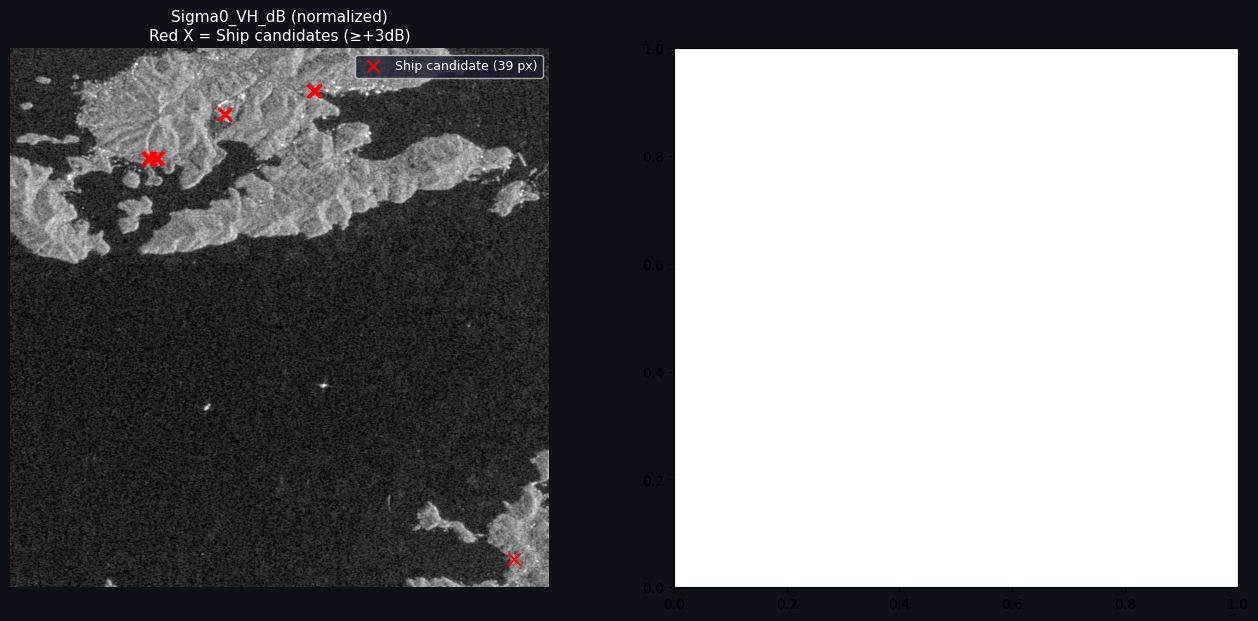

In [2]:
# ── 시각화: 정규화 이미지 + 선박 위치 표시 ──────────────
VH_MIN, VH_MAX = -35.0, -3.0
display = np.clip(sigma0_db, VH_MIN, VH_MAX)
display = (display - VH_MIN) / (VH_MAX - VH_MIN)
display[nodata_mask] = 0

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.patch.set_facecolor('#0d1117')

# 전체 이미지 + 선박 위치
axes[0].imshow(display, cmap='gray', vmin=0, vmax=1)
if ship_mask.sum() > 0:
    axes[0].scatter(ship_cols, ship_rows,
                    c='red', s=80, marker='x',
                    linewidths=1.5, label=f'Ship candidate ({ship_mask.sum()} px)')
axes[0].set_title('Sigma0_VH_dB (normalized)\nRed X = Ship candidates (≥+3dB)',
                   color='white', fontsize=11)
axes[0].legend(fontsize=9, facecolor='#1a1a2e', labelcolor='white')
axes[0].axis('off')

In [ ]:
# 선박 주변 확대 (첫 번째 선박 중심)
if ship_mask.sum() > 0:
    cr, cc = int(ship_rows.mean()), int(ship_cols.mean())
    pad = 100  # 픽셀 기준 ±100 (약 1km)
    r0, r1 = max(0, cr-pad), min(display.shape[0], cr+pad)
    c0, c1 = max(0, cc-pad), min(display.shape[1], cc+pad)
    crop = display[r0:r1, c0:c1]
    local_rows = ship_rows - r0
    local_cols = ship_cols - c0
    valid_idx = ((local_rows >= 0) & (local_rows < crop.shape[0]) &
                 (local_cols >= 0) & (local_cols < crop.shape[1]))

    axes[1].imshow(crop, cmap='gray', vmin=0, vmax=1)
    axes[1].scatter(local_cols[valid_idx], local_rows[valid_idx],
                    c='red', s=120, marker='x',
                    linewidths=2, label='Ship candidate')
    axes[1].set_title(f'확대: 선박 후보 중심 ±{pad}px (~{pad*10/1000:.1f}km)\n'
                      f'중심 좌표: ({gt[3]+cr*gt[5]:.4f}°N, {gt[0]+cc*gt[1]:.4f}°E)',
                      color='white', fontsize=11)
    axes[1].legend(fontsize=9, facecolor='#1a1a2e', labelcolor='white')
    axes[1].axis('off')

for ax in axes:
    ax.set_facecolor('#0d1117')

fig
# plt.tight_layout()
# plt.savefig('ship_candidates.png', dpi=150,
#             bbox_inches='tight', facecolor='#0d1117')
# plt.show()
# plt.close()
# print("선박 후보 시각화 저장: ship_candidates.png")

<Figure size 640x480 with 0 Axes>

선박 후보 시각화 저장: ship_candidates.png
